# Customer Churn Prediction

This project predicts whether a customer will churn or not using machine learning.

Steps:
- Exploratory Data Analysis
- Data preprocessing
- Decision Tree model
- Model evaluation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score,accuracy_score,confusion_matrix

In [5]:
churn_data=pd.read_excel(r"C:\Users\91917\Downloads\Telco_customer_churn.xlsx")

In [6]:
churn_data.info()
# churn_data.isnull().sum()
churn_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
churn_data=churn_data.drop(columns=['CustomerID',
    'Churn Label',
    'Churn Score',
    'Churn Reason',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude','Count'])

In [8]:
churn_data.isnull().sum()
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

# EDA

([<matplotlib.patches.Wedge at 0x28dd27fbb60>,
 [Text(-0.7393678155529122, 0.8144539479458092, 'No'),
  Text(0.7393680809356542, -0.8144537070291521, 'Yes')],
 [Text(-0.40329153575613386, 0.4442476079704413, '73.5%'),
  Text(0.4032916805103568, -0.44424747656135566, '26.5%')])

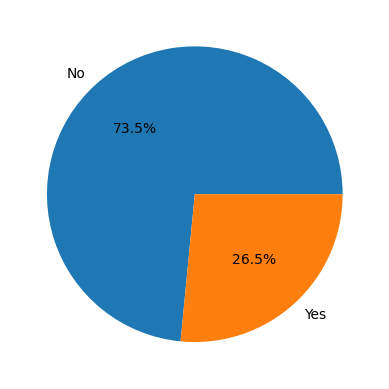

In [9]:
total=churn_data["Churn Value"].value_counts()
plt.pie(total,labels=["No","Yes"],autopct="%1.1f%%")

In [10]:
total

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [13]:
churn_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


<Axes: xlabel='Dependents', ylabel='Churn Value'>

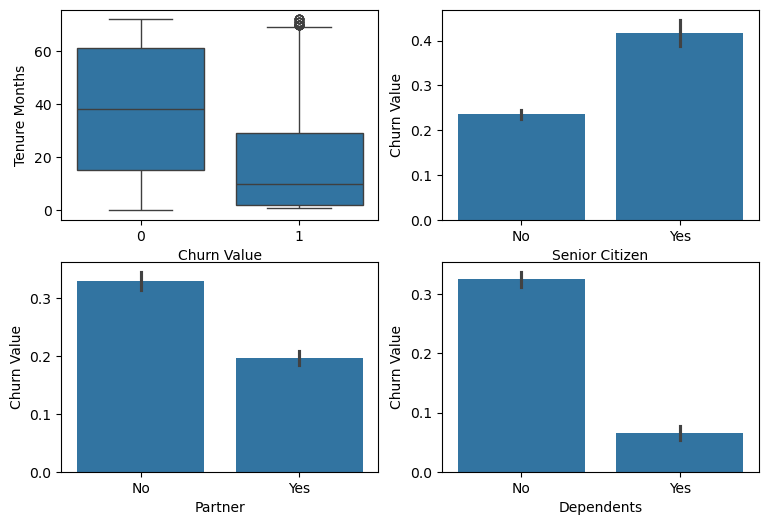

In [17]:
fig,axes=plt.subplots(2,2,figsize=(9,6))

sns.boxplot(ax=axes[0,0],data=churn_data,x="Churn Value",y="Tenure Months")
sns.barplot(ax=axes[0,1],data=churn_data,x="Senior Citizen",y="Churn Value")
sns.barplot(ax=axes[1,0],data=churn_data,x="Partner",y="Churn Value")
sns.barplot(ax=axes[1,1],data=churn_data,x="Dependents",y="Churn Value")

<Axes: xlabel='Tenure Months', ylabel='Count'>

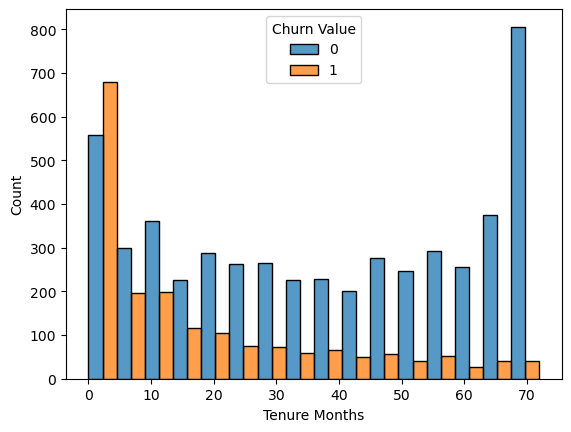

In [18]:
fig,axes=plt.subplots(1,2,figsize=(9,6))

sns.boxplot(ax=axes[0,0],data=churn_data,x="Churn Value",y="Tenure Months")
sns.barplot(ax=axes[0,1],data=churn_data,x="Senior Citizen",y="Churn Value")

sns.histplot(data=churn_data,x="Tenure Months",hue="Churn Value",multiple="dodge")


In [ ]:
sns.histplot(data=churn_data,x="CLTV",hue="Churn Value",multiple="dodge")

In [ ]:
sns.boxplot(data=churn_data,x="Churn Value",y="CLTV")

# one hot encoding for categorical data

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown='ignore')

encoded=ohe.fit_transform(churn_data[["Gender","Senior Citizen","Partner",
                    "Dependents","Phone Service","Multiple Lines",
                    "Internet Service","Online Security","Online Backup","Device Protection",
                   "Tech Support","Streaming TV","Streaming Movies","Contract","Paperless Billing",
                    "Payment Method"]])
                
 

In [ ]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(["Gender","Senior Citizen","Partner",
                    "Dependents","Phone Service","Multiple Lines",
                    "Internet Service","Online Security","Online Backup","Device Protection",
                   "Tech Support","Streaming TV","Streaming Movies","Contract","Paperless Billing",
                    "Payment Method"]),index=churn_data.index)

In [ ]:
churn_data=pd.concat([churn_data.drop(columns=["Gender","Senior Citizen","Partner",
                    "Dependents","Phone Service","Multiple Lines",
                    "Internet Service","Online Security","Online Backup","Device Protection",
                   "Tech Support","Streaming TV","Streaming Movies","Contract","Paperless Billing",
                    "Payment Method"]),encoded_df],axis=1)

In [ ]:
churn_data.head()

In [ ]:
#(churn_data["Total Charges"]==" ").sum()
churn_data["Total Charges"].apply(pd.to_numeric, errors='coerce').isna().sum()
churn_data.replace([''," ","--","NA","N/A","NULL"],
                   np.nan,
                  inplace=True)

In [ ]:
churn_data.isnull().sum()

In [ ]:
from sklearn.impute import SimpleImputer

si=SimpleImputer(strategy="mean")

churn_data[["Total Charges"]]=si.fit_transform(churn_data[["Total Charges"]])

In [ ]:
churn_data.isnull().sum()

In [ ]:
num_col=churn_data.select_dtypes(include="number")
corr_matrix=num_col.corr()

plt.figure(figsize=(25,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.tight_layout()
plt.savefig("churn.png")
plt.show()


In [ ]:
churn_data["Tenure Months"]=churn_data["Tenure Months"]**2

In [ ]:
churn_data.head()
churn_data.info()

# model 

In [ ]:
X=churn_data.drop(columns=["Churn Value"])
y=churn_data["Churn Value"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
model=DecisionTreeClassifier(max_depth=4)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_train_pred=model.predict(X_train)

print("training precision_score:",precision_score(y_train,y_train_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV

DT=DecisionTreeClassifier()


params_grid={"max_depth":[2,4,6,7,8,9],
            "min_samples_split":[5,10,15,20,25,30],
            "min_samples_leaf":[2,5,3,4]
}

GSC=GridSearchCV(
    DT,
    params_grid,
    cv=5,
    scoring="precision"
    
)

GSC.fit(X_train,y_train)

print("best params",GSC.best_params_)

In [ ]:
model=DecisionTreeClassifier(max_depth= 2, min_samples_leaf= 2, min_samples_split= 5)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_train_pred=model.predict(X_train)

print("training precision_score:",precision_score(y_train,y_train_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))